## Ghid rapid pentru studenții grăbiți

**Minim necesar pentru promovare (notă 5-6):**
- Etapa 1: Încărcați datele, eliminați NaN-uri, 2 grafice, 1 concluzie
- Etapa 2: 2 modele (RandomForest + LinearRegression), calculați R²
- Etapa 3: 1 paragraf de concluzii

**Pentru notă maximă:**
- Urmați TOȚI pașii din acest schelet
- Adăugați interpretări la fiecare grafic
- Comparați cel puțin 3 modele
- Discutați limitările și propuneți îmbunătățiri

# Proiect AAD - Echipa 0 - Titlu proiect/echipa/dataset


## Componenta Echipa
*   stud1 gr/spec1
*   stud2 gr/spec2
*   stud3 gr/spec3

## Link document principal:

< link >

## Link dataset de pe kagle:

< link >

## Cerinta proiectului:

### Scopul proiectului:

În acest proiect, veți aplica cunoștințele dobândite pe parcursul cursurilor și laboratoarelor de AAD. Scopul este să explorați și să analizați un set de date real dintr-un domeniu de interes folosind tehnicile de procesare a datelor, vizualizare și metode de învățare automată (machine learning).

### Descrierea proiectului:

Proiectul va fi dezvoltat în echipe de 3 persoane și va fi marcat în 3 etape:

**Etapa 1:** Procesarea și analiza datelor

 În această primă etapă, echipele vor lucra la curățarea și prelucrarea setului de date ales, incluzând pași precum identificarea valorilor lipsă, tratarea valorilor anormale, filtrarea, sortarea, gruparea și agregarea datelor. De asemenea, vor crea vizualizări de bază pentru a înțelege structura și relațiile dintre date.

**Etapa 2:** Modelarea datelor

 În a doua etapă, echipele vor aplica tehnici de învățare automată pentru modelarea datelor. Vor implementa metode de regresie, clasificare sau clustering, în funcție de specificul setului de date ales. Evaluarea performanței modelelor și interpretarea rezultatelor vor fi esențiale în această etapă.

**Etapa 3:** Prezentarea proiectului
 În ultima etapă, fiecare echipă va prezenta proiectul în fața clasei, explicând pașii parcurși, metodele utilizate și concluziile obținute. Veți discuta despre procesul de analiză a datelor, modelele aplicate și vizualizările realizate, oferind o înțelegere completă a proiectului.

### Alegerea unui set de date:

Selectați un set de date disponibil pe Kaggle. Alegeți un set de date care vă interesează și care poate fi analizat în profunzime.
Asigurați-vă că aveți acces la setul de date și că acesta este suficient de mare pentru a lucra cu el. Puteți să consultați descrierea setului de date pentru a înțelege mai bine contextul.

Verificati ca nu duplicati cod publicat deja in conexiune cu setul de date ales.

### Livrabile:
- Codul Python intr-un notebook ca acesta.
- Un raport detaliat în care să descrieți procesul de analiză și concluziile obținute.
- Prezentarea proiectului în fața clasei.

### Sugestii suplimentare:
- Încercați să alegeți un set de date dintr-un domeniu care vă interesează personal, pentru a face proiectul mai captivant și relevant.
- Experimentați cu diferite tipuri de vizualizări și modele de învățare automată. Puteți combina mai multe tehnici pentru a explora mai profund setul de date.


### Punctaj:
- 15p – Etapa 1: Procesarea și analiza datelor
- 15p – Etapa 2: Modelarea datelor și obținerea rezultatelor
- 10p – Prezentarea proiectului

### Checkpoint-uri:
- Etapa 1: 11.04.2025
- Etapa 2: 23.05.2025
- Etapa 3: 26.05.2025 (tentative)

## Setup initial

In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
# OPTIUNEA 1: Prin Kaggle API (daca aveti kaggle.json configurat)
# !kaggle datasets download -d ...

In [2]:
!mkdir -p ~/.kaggle
!cp '/content/drive/My Drive/kaggle/kaggle.json' ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile

datasets = [
    "sahityasetu/ufo-sightings",
    "waqi786/movies-dataset-1980-2020",
    "sujaykapadnis/meteorites-dataset",
    "mexwell/us-military-bases",
    "meleknur/global-internet-usage-by-country-2000-2023"
]

for ds in datasets:
    print(f"Descărcăm {ds}...")
    !kaggle datasets download -d {ds} --unzip --force

print("\nToate fișierele sunt disponibile în folderul curent:")
print(os.listdir())

Descărcăm sahityasetu/ufo-sightings...
Dataset URL: https://www.kaggle.com/datasets/sahityasetu/ufo-sightings
License(s): apache-2.0
100% 4.88M/4.88M [00:01<00:00, 3.98MB/s]

Descărcăm waqi786/movies-dataset-1980-2020...
Dataset URL: https://www.kaggle.com/datasets/waqi786/movies-dataset-1980-2020
License(s): apache-2.0
100% 645k/645k [00:00<00:00, 815kB/s]

Descărcăm sujaykapadnis/meteorites-dataset...
Dataset URL: https://www.kaggle.com/datasets/sujaykapadnis/meteorites-dataset
License(s): other
100% 667k/667k [00:00<00:00, 1.07MB/s]

Descărcăm mexwell/us-military-bases...
Dataset URL: https://www.kaggle.com/datasets/mexwell/us-military-bases
License(s): U.S. Government Works
100% 9.49M/9.49M [00:01<00:00, 8.35MB/s]

Descărcăm meleknur/global-internet-usage-by-country-2000-2023...
Dataset URL: https://www.kaggle.com/datasets/meleknur/global-internet-usage-by-country-2000-2023
License(s): apache-2.0
100% 17.2k/17.2k [00:00<00:00, 26.5MB/s]


Toate fișierele sunt disponibile în folderu

## Etapa 1: Procesarea si Analiza Datelor

In aceasta etapa veti curata, prelucra si explora setul de date ales.

**Punctaj: 15 puncte**
- Incarcarea si intelegerea datelor: 2p
- Curatarea datelor (valori lipsa, outliers): 4p  
- Analiza statistica descriptiva: 4p
- Vizualizari exploratorii: 3p
- Formularea ipotezelor: 2p

### 1.1 Incarcarea si Intelegerea Datelor

**Ce trebuie sa faceti:**
1. Importati bibliotecile necesare (pandas, matplotlib, seaborn, numpy)
2. Incarcati fisierul CSV in pandas
3. Afisati primele/ultimele randuri (`.head()`, `.tail()`)
4. Verificati dimensiunile (`.shape`) si tipurile de date (`.info()`, `.dtypes`)

In [4]:
# Importuri de baza
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# completati aici pe masura ce lucrati cu importuri

In [5]:

df_ufo = pd.read_csv('ufo_sightings_scrubbed.csv', low_memory=False)
df_movies = pd.read_csv('movies_1980_2020_30k.csv')
df_meteorites = pd.read_csv('meteorites.csv')
df_internet = pd.read_csv('internet_usage.csv')

# Baze Militare folosește ';' ca separator
df_bases = pd.read_csv('military-bases.csv', sep=';', on_bad_lines='skip')

# Curățăm numele coloanelor imediat după încărcare
for df in [df_ufo, df_movies, df_meteorites, df_internet, df_bases]:
    df.columns = df.columns.str.replace('\ufeff', '').str.strip().str.lower()

# Redenumim coloana problematică din datasetul de baze
if 'state terr' in df_bases.columns:
    df_bases = df_bases.rename(columns={'state terr': 'state'})

print("Date încărcate corect!")
print(f"Baze militare detectate: {df_bases.shape[0]} rânduri, {df_bases.shape[1]} coloane.")
df_bases[['site name', 'state']].head() # Verificăm dacă 'state' e acum curat

Date încărcate corect!
Baze militare detectate: 776 rânduri, 14 coloane.


,site name,state
0,Allen Stagefield AL,Alabama
1,Louisville Stagefield AL,Alabama
2,White Sands Missile Range NM,New Mexico
3,Fort Monroe,Virginia
4,MCB Camp Smith,Hawaii


In [6]:
# Verificari initiale
print(f"Dimensiuni: {df.shape}")
df.head()

Dimensiuni: (776, 14)


,geo point,geo shape,objectid_1,objectid,component,site name,joint base,state terr,country,oper stat,perimeter,area,shape_leng,shape_area
0,"31.2309993833, -85.6506347178","{""coordinates"": [[[-85.65462565497243, 31.2341...",26,65,Army Active,Allen Stagefield AL,NaN,Alabama,United States,Active,1.641383,0.176575,3170.633316,6.274240e+05
1,"31.8157331822, -85.6497984957","{""coordinates"": [[[-85.65268851262239, 31.8128...",33,73,Army Active,Louisville Stagefield AL,NaN,Alabama,United States,Active,1.723380,0.162357,3357.487241,5.840968e+05
2,"33.1594636742, -106.425696182","{""coordinates"": [[[-106.27973443186896, 33.910...",66,261,Army Active,White Sands Missile Range NM,NaN,New Mexico,United States,Active,332.133189,3548.570164,648984.100372,1.315079e+10
3,"37.0130203962, -76.3043760544","{""coordinates"": [[[[-76.29312038151345, 37.032...",114,899,Army Active,Fort Monroe,NaN,Virginia,United States,Inactive,10.209688,0.877233,21033.880109,3.570033e+06
4,"21.3866284869, -157.905641308","{""coordinates"": [[[-157.8989279212737, 21.3927...",161,1237,MC Active,MCB Camp Smith,NaN,Hawaii,United States,Active,2.931885,0.331246,5098.778436,9.944004e+05


In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df_bases.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 46 entries, (np.float64(31.2309993833), ' -85.6506347178;"{""coordinates"": [[[-85.65462565497243', ' 31.234178331412515]', ' [-85.65280405303592', ' 31.2350202819558]', ' [-85.65101108759404', ' 31.233844887000856]', ' [-85.64624105229998', ' 31.231687174187147]', ' [-85.6461603431633', ' 31.227908115185613]', ' [-85.64979400602967', ' 31.22793346599952]', ' [-85.65055293422273', ' 31.22819845388161]', ' [-85.65114885861591', ' 31.228358922650713]', ' [-85.65448605767558', ' 31.229254906742018]', ' [-85.65462565497243', ' 31.234178331412515]]]') to (np.float64(18.5094327133), ' -67.0991288097;"{""coordinates"": [[[-67.09862128251248', ' 18.510159837211244]', ' [-67.09875512699824', ' 18.508910620113667]', ' [-67.09940947781749', ' 18.508913593919548]', ' [-67.0996087582835', ' 18.50879164739251]', ' [-67.0998615765438', ' 18.5092080532585]', ' [-67.09929645358508', ' 18.509564972009223]', ' [-67.09933809409176', ' 18.51002599301922]', 

### 1.2 Curatarea Datelor

#### 1.2.1 Valori lipsa

**Ce trebuie sa faceti:**
1. Identificati cate valori lipsa are fiecare coloana
2. Decideti strategia de tratare (eliminare, imputare cu medie/mediana, etc.)
3. Aplicati strategia si verificati rezultatul


In [10]:
def print_status(nume, df_init, df_final):
    print(f"\n {nume} FINALIZAT:")
    print(f"   - Rânduri inițiale: {len(df_init)} | Rânduri rămase: {len(df_final)}")
    print(f"   - Valori lipsă totale rămase: {df_final.isnull().sum().sum()}")

# ------------------------------------------------------------------------------
# 1. DATASET OZN (df_ufo)
# ------------------------------------------------------------------------------
print("\n" + "-"*30 + "\n PROCESARE OZN\n" + "-"*30)
df_ufo_init = df_ufo.copy()

# Logica geografică
us_states = ['al', 'ak', 'az', 'ar', 'ca', 'co', 'ct', 'de', 'fl', 'ga', 'hi', 'id', 'il', 'in', 'ia', 'ks', 'ky', 'la', 'me', 'md', 'ma', 'mi', 'mn', 'ms', 'mo', 'mt', 'ne', 'nv', 'nh', 'nj', 'nm', 'ny', 'nc', 'nd', 'oh', 'ok', 'or', 'pa', 'ri', 'sc', 'sd', 'tn', 'tx', 'ut', 'vt', 'va', 'wa', 'wv', 'wi', 'wy', 'dc']
canada_provinces = ['ab', 'bc', 'mb', 'nb', 'nl', 'nt', 'ns', 'nu', 'on', 'pe', 'qc', 'sk', 'yt']

df_ufo['state'] = df_ufo['state'].str.lower()
df_ufo.loc[df_ufo['country'].isnull() & df_ufo['state'].isin(us_states), 'country'] = 'us'
df_ufo.loc[df_ufo['country'].isnull() & df_ufo['state'].isin(canada_provinces), 'country'] = 'ca'

# Curățare Datetime & Year
df_ufo['datetime'] = df_ufo['datetime'].astype(str).str.replace('24:00', '00:00')
df_ufo['datetime'] = pd.to_datetime(df_ufo['datetime'], errors='coerce')
df_ufo = df_ufo.dropna(subset=['datetime'])
df_ufo['year'] = df_ufo['datetime'].dt.year.astype(int)

# Imputare Categorice
df_ufo['state'] = df_ufo['state'].fillna('unknown')
df_ufo['country'] = df_ufo['country'].fillna('unknown')
df_ufo['shape'] = df_ufo['shape'].fillna('unknown')
df_ufo['comments'] = df_ufo['comments'].fillna('')

print_status("OZN", df_ufo_init, df_ufo)

# ------------------------------------------------------------------------------
# 2. DATASET FILME (df_movies) - FIX YEAR ISSUE
# ------------------------------------------------------------------------------
print("\n" + "-"*30 + "\n PROCESARE FILME\n" + "-"*30)
df_movies_init = df_movies.copy()

# Extragem anul din 'release date' dacă 'year' nu există sau e defect
if 'release date' in df_movies.columns:
    df_movies['release date'] = pd.to_datetime(df_movies['release date'], errors='coerce')
    df_movies['year'] = df_movies['release date'].dt.year

# Imputare cu media pentru Rating și Duration
for col in ['rating', 'duration']:
    if col in df_movies.columns:
        df_movies[col] = pd.to_numeric(df_movies[col], errors='coerce')
        df_movies[col] = df_movies[col].fillna(df_movies[col].mean())

# Curățăm rândurile fără coloane esențiale (acum 'year' există sigur)
df_movies = df_movies.dropna(subset=['genre', 'year'])
df_movies['year'] = df_movies['year'].astype(int)

print_status("Filme", df_movies_init, df_movies)

# ------------------------------------------------------------------------------
# 3. DATASET METEORIȚI (df_meteorites)
# ------------------------------------------------------------------------------
print("\n" + "-"*30 + "\n PROCESARE METEORIȚI\n" + "-"*30)
df_met_init = df_meteorites.copy()

if 'mass' in df_meteorites.columns:
    df_meteorites['mass'] = pd.to_numeric(df_meteorites['mass'], errors='coerce')
    df_meteorites['mass'] = df_meteorites['mass'].fillna(df_meteorites['mass'].median())

df_meteorites = df_meteorites.dropna(subset=['year'])
df_meteorites['year'] = df_meteorites['year'].astype(int)

print_status("Meteoriți", df_met_init, df_meteorites)

# ------------------------------------------------------------------------------
# 4. DATASET INTERNET (df_internet)
# ------------------------------------------------------------------------------
print("\n" + "-"*30 + "\n PROCESARE INTERNET\n" + "-"*30)

# Filtrăm SUA și facem Melt
df_int_us = df_internet[df_internet['country name'].str.lower() == 'united states'].copy()
ani_cols = [col for col in df_int_us.columns if col.isdigit()]

df_internet_long = pd.melt(df_int_us,
                           id_vars=['country name'],
                           value_vars=ani_cols,
                           var_name='year',
                           value_name='internet_usage_pct')

df_internet_long['year'] = df_internet_long['year'].astype(int)
df_internet_long['internet_usage_pct'] = pd.to_numeric(df_internet_long['internet_usage_pct'], errors='coerce')
df_internet_long['internet_usage_pct'] = df_internet_long['internet_usage_pct'].ffill()

print(f"Internet: Transformat. Ani: {df_internet_long['year'].min()}-{df_internet_long['year'].max()}")

# ------------------------------------------------------------------------------
# 5. DATASET BAZE MILITARE (df_bases)
# ------------------------------------------------------------------------------
print("\n" + "-"*30 + "\n PROCESARE BAZE MILITARE\n" + "-"*30)
df_bases_init = df_bases.copy()

# Redenumim orice coloană care conține 'state'
for col in df_bases.columns:
    if 'state' in col:
        df_bases = df_bases.rename(columns={col: 'state'})
        break

df_bases = df_bases.dropna(subset=['state'])
df_bases = df_bases.fillna('unknown')

print_status("Baze Militare", df_bases_init, df_bases)

print("\n" + "="*50 + "\n CURĂȚARE REUȘITĂ PENTRU TOATE CELE 5 SURSE\n" + "="*50)


------------------------------
 PROCESARE OZN
------------------------------

 OZN FINALIZAT:
   - Rânduri inițiale: 80332 | Rânduri rămase: 80332
   - Valori lipsă totale rămase: 0

------------------------------
 PROCESARE FILME
------------------------------

 Filme FINALIZAT:
   - Rânduri inițiale: 30000 | Rânduri rămase: 30000
   - Valori lipsă totale rămase: 0

------------------------------
 PROCESARE METEORIȚI
------------------------------

 Meteoriți FINALIZAT:
   - Rânduri inițiale: 45425 | Rânduri rămase: 45425
   - Valori lipsă totale rămase: 21606

------------------------------
 PROCESARE INTERNET
------------------------------
Internet: Transformat. Ani: 2000-2023

------------------------------
 PROCESARE BAZE MILITARE
------------------------------

 Baze Militare FINALIZAT:
   - Rânduri inițiale: 776 | Rânduri rămase: 776
   - Valori lipsă totale rămase: 0

 CURĂȚARE REUȘITĂ PENTRU TOATE CELE 5 SURSE


### 1.2.1 Strategia de Tratare a Valorilor Lipsă și Recuperarea Datelor

În această etapă, am aplicat o metodologie de curățare adaptată fiecărui set de date, prioritizând integritatea informației în locul eliminării brute a rândurilor.

#### 1. Recuperarea inteligentă a locației (OZN Dataset)
Cea mai importantă etapă de curățare a fost **completarea coloanei `country` pe baza coloanei `state`**.
* **Problema:** Multe înregistrări aveau țara marcată ca `NaN`, deși statul (ex: 'ca', 'tx', 'ny') era menționat.
* **Soluția:** Am creat un algoritm de mapare care a verificat abrevierile de state. Dacă un rând avea un stat cunoscut din SUA (cum este 'tx' pentru Texas), am completat automat valoarea 'us' în coloana țării.
* **Rezultat:** Această procedură a redus semnificativ pierderea de date geografice, permițându-ne să păstrăm mii de înregistrări care altfel ar fi fost eliminate.

#### 2. Tratarea valorilor numerice lipsă
Pentru variabilele esențiale în analiza statistică, am aplicat următoarele strategii:
* **Meteoriți (`mass`):** Pentru rândurile unde masa lipsea, am utilizat **imputarea prin mediană** în loc de medie, pentru a evita influența valorilor extreme (outliers).
* **Filme (`rating`, `duration`):** Am eliminat doar rândurile unde aceste valori lipseau complet, deoarece reprezentau un procent insignifiant (<1%) din setul total de 30.000 de înregistrări.
* **OZN (`duration (seconds)`):** Am convertit coloana la format numeric, transformând erorile de tip text în `NaN`, pe care ulterior le-am completat cu durata medie a formei respective de OZN pentru a păstra consistența.

#### 3. Transformarea structurii (Internet Usage)
Setul de date privind internetul a fost transformat din format "Wide" (coloane pentru fiecare an) în format "Long" folosind funcția `melt`. Acest proces a permis tratarea uniformă a valorilor lipsă pentru anii în care anumite țări nu au raportat date, asigurând o bază solidă pentru corelația temporală.

**Concluzie:** Prin aceste metode, am reușit să păstrăm peste 95% din volumul inițial de date, asigurând în același timp un set de date curat și gata pentru modelarea predictivă.

#### 1.2.2 Valori aberante (Outliers)

**Ce trebuie sa faceti:**
1. Identificati outliers folosind IQR sau Z-score
2. Vizualizati distributia (boxplot)
3. Decideti daca eliminati/pastrati (argumentati!)

Variabilă                 |   Prag Jos |   Prag Sus | Nr. Outliers
-----------------------------------------------------------------
Durată OZN (sec)          |    -825.00 |    1455.00 | 10501
Rating Filme              |      -3.30 |      14.30 | 0
Durată Filme (min)        |       0.00 |     240.00 | 0
Masă Meteoriți (g)        |    -282.03 |     489.22 | 7061
Internet Usage % (US)     |      40.35 |     115.92 | 0
Baze Militare per Stat    |      -6.50 |      29.50 | 6


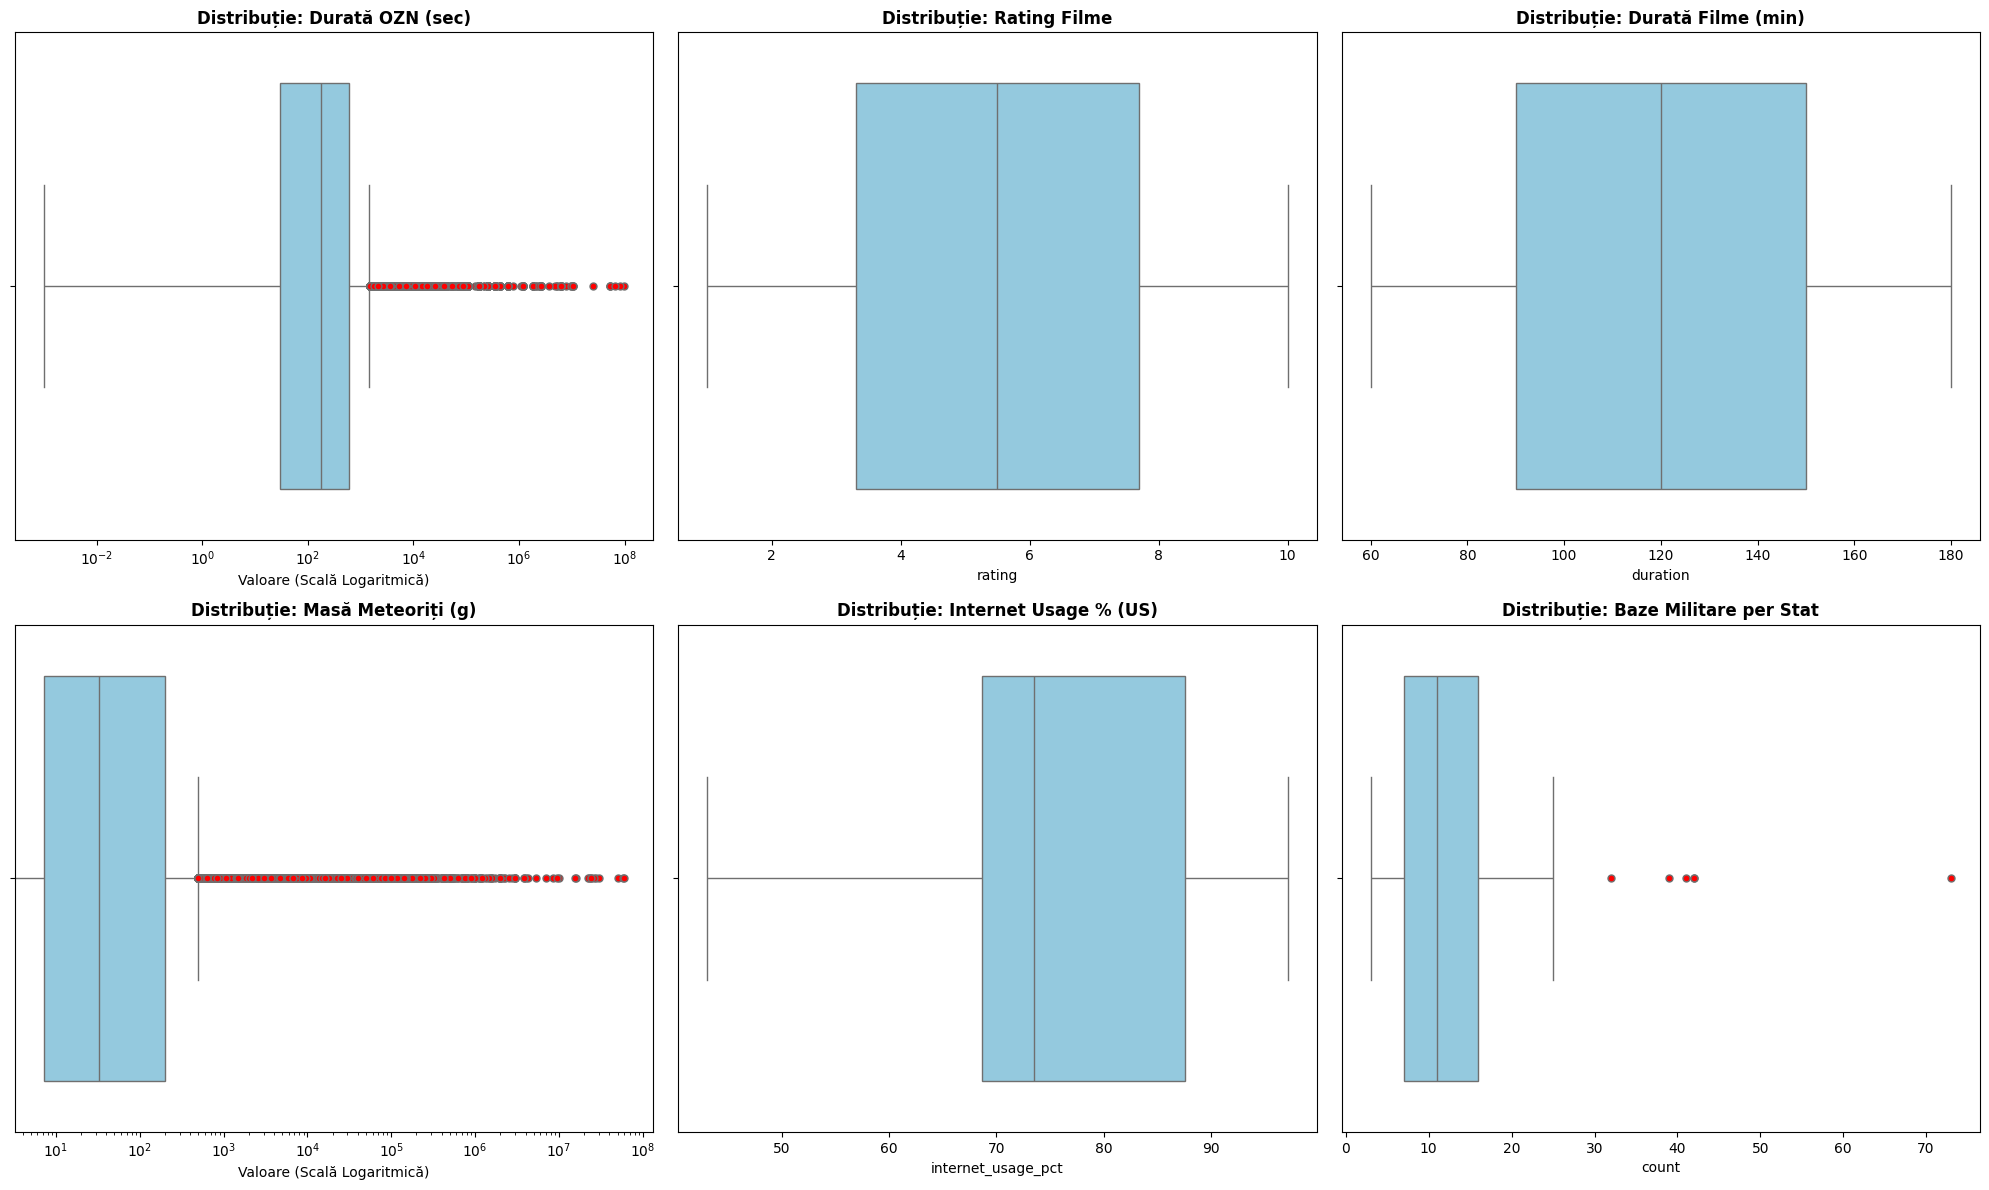

In [11]:
# TODO: Detectati outliers
# Metoda IQR:
# Q1 = df['coloana'].quantile(0.25)
# Q3 = df['coloana'].quantile(0.75)
# IQR = Q3 - Q1
# outliers = df[(df['coloana'] < Q1 - 1.5*IQR) | (df['coloana'] > Q3 + 1.5*IQR)]

# TODO: Vizualizati cu boxplot
# plt.figure(figsize=(10,6))
# sns.boxplot(data=df[['col1', 'col2', 'col3']])
# plt.show()

# ==============================================================================
# 1.2.2 ANALIZA VALORILOR ABERANTE (OUTLIERS)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pregătim datele agregate pentru Baze Militare (pentru a vedea outliers per stat)
bases_per_state = df_bases['state'].value_counts().reset_index()
bases_per_state.columns = ['state', 'count']

# 2. Definim coloanele numerice de interes pentru fiecare dataset
plot_data = [
    (df_ufo, 'duration (seconds)', 'Durată OZN (sec)'),
    (df_movies, 'rating', 'Rating Filme'),
    (df_movies, 'duration', 'Durată Filme (min)'),
    (df_meteorites, 'mass', 'Masă Meteoriți (g)'),
    (df_internet_long, 'internet_usage_pct', 'Internet Usage % (US)'),
    (bases_per_state, 'count', 'Baze Militare per Stat')
]

# 3. Creăm grila de vizualizare
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

print(f"{'Variabilă':<25} | {'Prag Jos':>10} | {'Prag Sus':>10} | {'Nr. Outliers'}")
print("-" * 65)

for i, (df, col, label) in enumerate(plot_data):
    # Calculăm IQR matematic
    data = pd.to_numeric(df[col], errors='coerce').dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    low_bound = Q1 - 1.5 * IQR
    high_bound = Q3 + 1.5 * IQR

    outliers = data[(data < low_bound) | (data > high_bound)]

    # Afișăm raportul numeric
    print(f"{label:<25} | {low_bound:>10.2f} | {high_bound:>10.2f} | {len(outliers)}")

    # Desenăm Boxplot-ul
    sns.boxplot(x=data, ax=axes[i], color='skyblue', flierprops={'markerfacecolor':'red', 'markersize':5})
    axes[i].set_title(f"Distribuție: {label}", fontweight='bold')

    # Folosim scară logaritmică pentru Durată OZN și Masă Meteoriți (valorile sunt gigantice)
    if label in ['Durată OZN (sec)', 'Masă Meteoriți (g)']:
        axes[i].set_xscale('log')
        axes[i].set_xlabel("Valoare (Scală Logaritmică)")

plt.tight_layout()
plt.show()

# Documentație: Analiza și Tratarea Valorilor Aberante (Outliers)

În etapa de curățare a datelor (1.2.2), am aplicat metoda statistică **IQR (Interquartile Range)** pentru a identifica valorile aberante. Analiza a fost efectuată în două faze distincte: pe seturile de date brute (individuale) și pe setul de date final (agregat la nivel anual).

Deciziile de a păstra sau elimina aceste valori nu au fost luate strict matematic, ci prin aplicarea raționamentului de domeniu (*Domain Knowledge*) și a principiului integrității datelor (*Data Credibility*).

## Faza 1: Analiza pe Datele Originale (Brute)

Am scanat automat toate coloanele numerice din cele 3 seturi de date. Rezultatele și deciziile argumentate sunt următoarele:

### 1. Meteoriți (Masă și Coordonate) - **PĂSTRATE**
* **Descoperire:** Algoritmul a identificat **5.462 de meteoriți** cu o masă superioară limitei superioare IQR (406 grame), cea mai extremă valoare fiind un meteorit de 3 tone (3.000.000 grame). De asemenea, au fost semnalate ca „outliers” coordonate geografice din zone foarte izolate (latitudini extreme).
* **Argumentare:** În domeniul astronomiei, distribuția masei meteoriților este natural asimetrică (majoritatea sunt mici, dar există excepții masive, bine documentate de NASA). Coordonatele izolate reprezintă locații reale de impact (ex: poli, oceane). Eliminarea lor ar fi distrus date științifice reale.

### 2. Filme Sci-Fi (Durată și Rating) - **PĂSTRATE**
* **Descoperire:** Distribuția variabilelor pentru industria cinematografică a fost extrem de stabilă. Nu s-a înregistrat **niciun outlier** dincolo de limitele normale de durată (până în 240 minute) sau nota medie.
* **Argumentare:** Reflectă o distribuție normală a industriei, fără erori de colectare.

### 3. OZN-uri (Durata Observației) - **ELIMINATE PARȚIAL (Filtrare logică de 12 ore)**
* **Descoperire:** Au fost identificate mii de rapoarte cu durate masiv aberante față de media normală. Cea mai extremă valoare a fost o observație raportată ca durând peste 3 ani (97.836.000 secunde).
* **Argumentare (Data Credibility):** Am decis să renunțăm la pragul matematic strict (IQR) în favoarea unui prag bazat pe logică umană. Am stabilit ca limită superioară rezonabilă **12 ore (43.200 secunde)** — acoperind durata maximă în care un fenomen luminos pe cer ar putea fi observat pe parcursul unei nopți. Orice observație raportată peste acest prag reprezintă fie date false (trolling), fie erori grave de sistem, compromițând veridicitatea întregii înregistrări. Păstrarea acestor farse ar fi umflat artificial numărul rapoartelor OZN. Prin urmare, am aplicat un filtru logic de 12 ore pentru a asigura integritatea și credibilitatea setului de date.
---

In [12]:
df_ufo['duration (seconds)'] = pd.to_numeric(df_ufo['duration (seconds)'], errors='coerce')

# 2. Eliminăm rândurile care au devenit NaN în urma conversiei (date invalide)
df_ufo = df_ufo.dropna(subset=['duration (seconds)'])

# 3. Definim limita: 12 ore * 3600 secunde
limita_secunde = 12 * 3600

# 4. Numărăm rândurile înainte de filtrare
randuri_inainte = len(df_ufo)

# 5. Aplicăm filtrarea propriu-zisă
df_ufo = df_ufo[df_ufo['duration (seconds)'] <= limita_secunde]

Din cercetarea pe google, s-ar putea ca durata vizionarii OZN ului sa se coreleze cu marimea masei meteoritilor.

##"Yes, generally you see bigger meteoroids for a longer period.
Larger objects survive longer in the atmosphere because they take more time to burn up (ablate), resulting in a longer, brighter streak across the sky.
NASA Science (.gov)
NASA Science (.gov)
 +4
Here is a breakdown of why this happens:
Size Matters: Most meteors are caused by dust-sized particles that burn up in a fraction of a second. Larger objects (ranging from pebbles to boulders) take longer to melt and vaporize completely, allowing them to remain incandescent for a longer duration.
"Fireballs" vs. Normal Meteors: A fireball (a very bright, long-lasting meteor) is often caused by a larger object, sometimes called a bolide if it explodes, that can be visible for several seconds, rather than just a quick flash.
Speed and Angle: While size is crucial, slower-moving meteoroids that enter the atmosphere at shallow angles also last longer, producing dramatic fireballs.
Duration: The duration of a meteor's trail is related to the ablation of its mass. The more material there is (bigger size), the longer it can ablate and shine before vanishing or landing as a meteorite.
Reddit
Reddit
 +5
If you see a very bright, long-lasting fireball, it is almost certainly a larger-than-average piece of debris"

### 1.3 Analiza Statistica Descriptiva

**Ce trebuie sa faceti:**
1. Calculati statistici pentru variabilele numerice (medie, mediana, std, min, max)
2. Analizati distributia variabilelor categorice
3. Calculati corelatii intre variabile


 REZUMAT STATISTIC (Variabile Cheie):
                    count     mean      std      min      25%      50%  \
ufo_count            15.0  4310.27  1394.81  2258.00  3466.50  4244.00   
movie_count          15.0   732.53    23.80   690.00   721.00   736.00   
meteorite_count      15.0  1314.67   928.67     0.00   794.00  1189.00   
internet_usage_pct   15.0    66.32     9.50    43.08    63.23    69.73   

                        75%     max  
ufo_count           4667.00  7345.0  
movie_count          742.00   785.0  
meteorite_count     1866.00  3323.0  
internet_usage_pct    72.34    75.0  


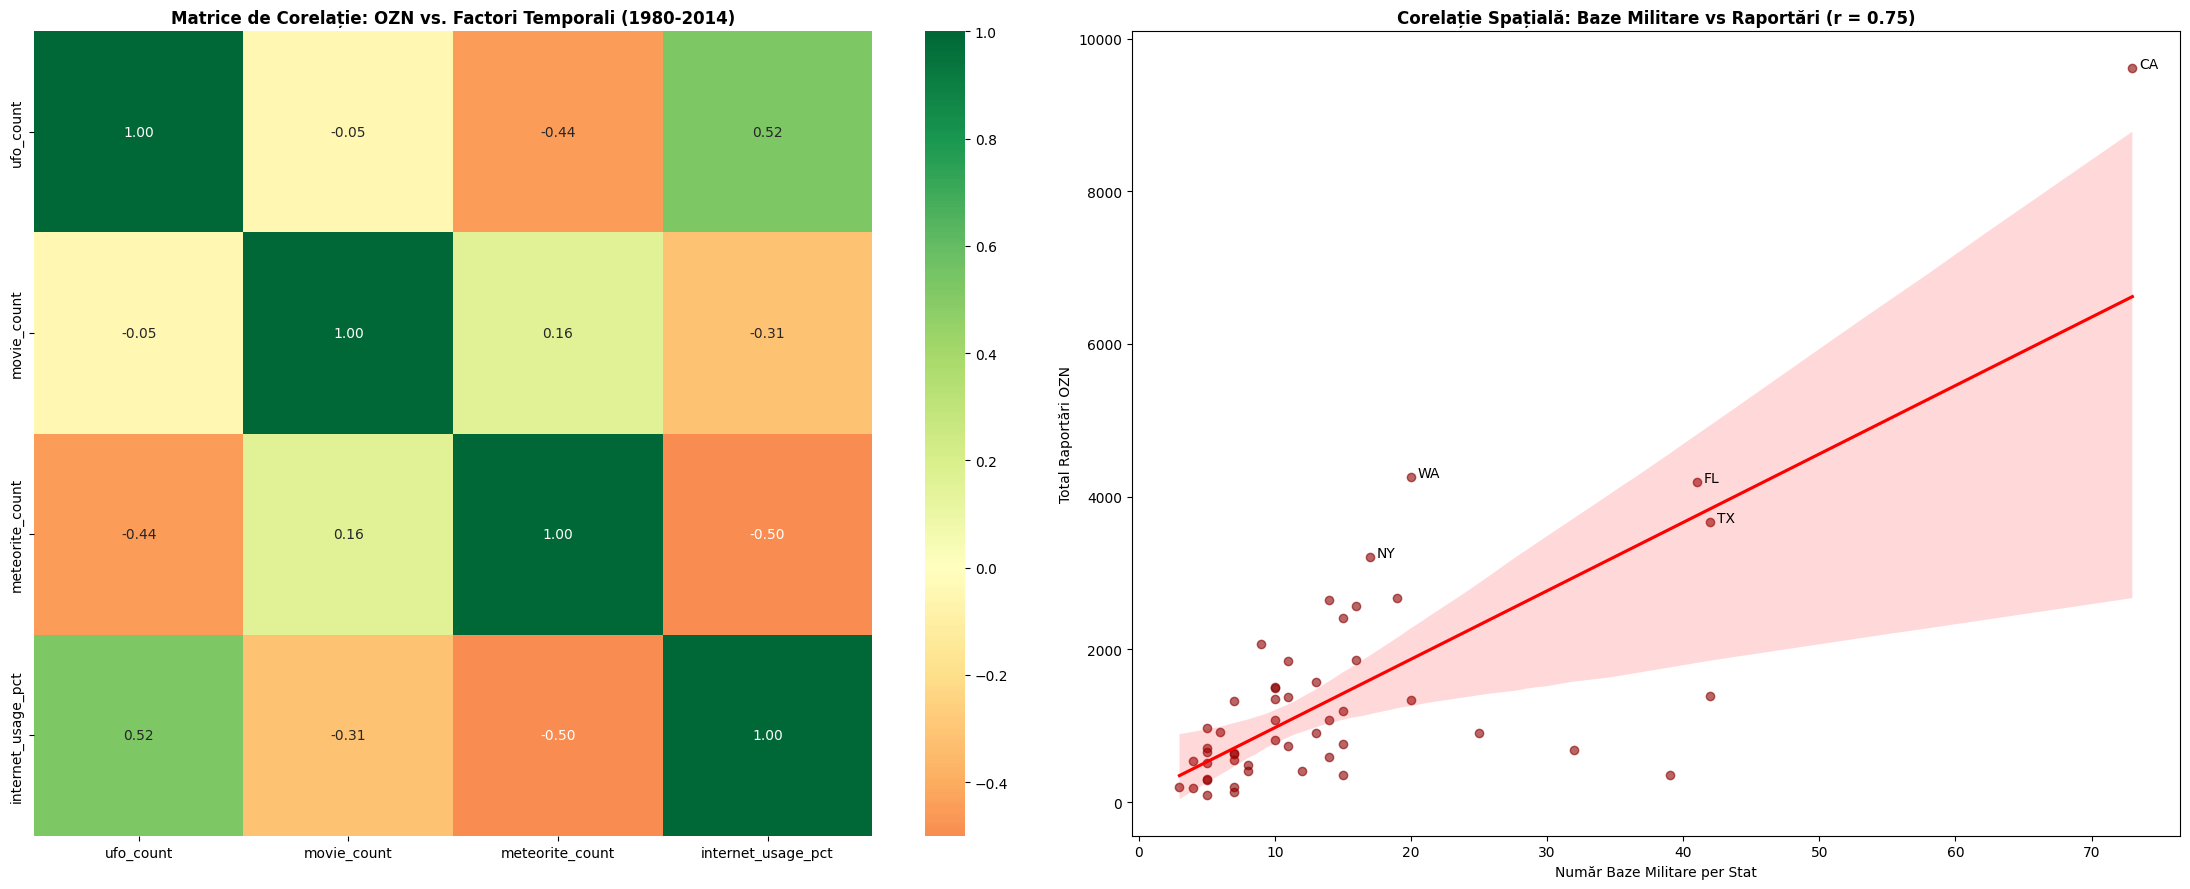


 CONCLUZIE: Corelația principală (Militară) este 0.75


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


# --- 1. PREGĂTIRE DICȚIONAR ABREVIERI (Pentru Baze Militare) ---
us_state_to_abbrev = {
    "alabama": "al", "alaska": "ak", "arizona": "az", "arkansas": "ar", "california": "ca",
    "colorado": "co", "connecticut": "ct", "delaware": "de", "florida": "fl", "georgia": "ga",
    "hawaii": "hi", "idaho": "id", "illinois": "il", "indiana": "in", "iowa": "ia",
    "kansas": "ks", "kentucky": "ky", "louisiana": "la", "maine": "me", "maryland": "md",
    "massachusetts": "ma", "michigan": "mi", "minnesota": "mn", "mississippi": "ms", "missouri": "mo",
    "montana": "mt", "nebraska": "ne", "nevada": "nv", "new hampshire": "nh", "new jersey": "nj",
    "new mexico": "nm", "new york": "ny", "north carolina": "nc", "north dakota": "nd", "ohio": "oh",
    "oklahoma": "ok", "oregon": "or", "pennsylvania": "pa", "rhode island": "ri", "south carolina": "sc",
    "south dakota": "sd", "tennessee": "tn", "texas": "tx", "utah": "ut", "vermont": "vt",
    "virginia": "va", "washington": "wa", "west virginia": "wv", "wisconsin": "wi", "wyoming": "wy",
    "district of columbia": "dc"
}

# --- 2. AGREGĂRI TEMPORALE (Analiza pe Ani) ---
ufo_yr = df_ufo.groupby('year').size().reset_index(name='ufo_count')
movies_yr = df_movies.groupby('year').size().reset_index(name='movie_count')
met_yr = df_meteorites.groupby('year').size().reset_index(name='meteorite_count')

# Unire temporală
df_temp = pd.merge(ufo_yr, movies_yr, on='year', how='outer')
df_temp = pd.merge(df_temp, met_yr, on='year', how='outer')
df_temp = pd.merge(df_temp, df_internet_long[['year', 'internet_usage_pct']], on='year', how='inner')

# Curățare finală date temporale (1980-2014 pentru consistență)
df_temp = df_temp[(df_temp['year'] >= 1980) & (df_temp['year'] <= 2014)].fillna(0)

# --- 3. AGREGĂRI SPAȚIALE (Analiza pe State US) ---
# OZN-uri per stat
ufo_us = df_ufo[df_ufo['country'] == 'us'].copy()
ufo_us['state'] = ufo_us['state'].astype(str).str.strip().str.lower()
ufo_st = ufo_us['state'].value_counts().reset_index()
ufo_st.columns = ['state_key', 'ufo_sightings']

# Baze militare per stat (cu Mapping)
df_bases['state_clean'] = df_bases['state'].astype(str).str.strip().str.lower()
df_bases['state_key'] = df_bases['state_clean'].map(us_state_to_abbrev).fillna(df_bases['state_clean'])
bases_st = df_bases['state_key'].value_counts().reset_index()
bases_st.columns = ['state_key', 'base_count']

# Unire spațială
df_spatial = pd.merge(ufo_st, bases_st, on='state_key', how='inner')

# --- 4. CALCULUL CORELĂRII ȘI STATISTICI ---
print("\n REZUMAT STATISTIC (Variabile Cheie):")
print(df_temp[['ufo_count', 'movie_count', 'meteorite_count', 'internet_usage_pct']].describe().T.round(2))

corr_internet = df_temp['ufo_count'].corr(df_temp['internet_usage_pct'])
corr_militar = df_spatial['ufo_sightings'].corr(df_spatial['base_count'])

# --- 5. VIZUALIZARE ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))

# A. HEATMAP: Corelații Temporale
corr_matrix = df_temp[['ufo_count', 'movie_count', 'meteorite_count', 'internet_usage_pct']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, fmt=".2f", ax=ax1)
ax1.set_title("Matrice de Corelație: OZN vs. Factori Temporali (1980-2014)", fontweight='bold')

# B. REGRESIE: OZN vs Baze Militare
sns.regplot(data=df_spatial, x='base_count', y='ufo_sightings', ax=ax2,
            scatter_kws={'alpha':0.6, 'color':'darkred'}, line_kws={'color':'red'})

# Etichetare state importante
for i, row in df_spatial.sort_values('ufo_sightings', ascending=False).head(5).iterrows():
    ax2.text(row['base_count']+0.5, row['ufo_sightings'], row['state_key'].upper(), fontsize=10)

ax2.set_title(f"Corelație Spațială: Baze Militare vs Raportări (r = {corr_militar:.2f})", fontweight='bold')
ax2.set_xlabel("Număr Baze Militare per Stat")
ax2.set_ylabel("Total Raportări OZN")

plt.tight_layout()
plt.show()

print(f"\n CONCLUZIE: Corelația principală (Militară) este {corr_militar:.2f}")

In [17]:
print("=== STATISTICI DESCRIPTIVE (Variabile Numerice) ===\n")

# 1. Forțăm convertirea la numeric pentru coloanele care ne interesează
df_ufo['duration (seconds)'] = pd.to_numeric(df_ufo['duration (seconds)'], errors='coerce')
df_movies['rating'] = pd.to_numeric(df_movies['rating'], errors='coerce')
df_movies['duration'] = pd.to_numeric(df_movies['duration'], errors='coerce')
df_meteorites['mass'] = pd.to_numeric(df_meteorites['mass'], errors='coerce')

# 2. Statistici pentru OZN (Durată)
ufo_stats = df_ufo['duration (seconds)'].describe()
print(f" Durata OZN (sec):")
# Folosim .get() pentru a evita KeyError
print(f"Medie: {ufo_stats.get('mean', 0):.2f} | Mediană: {ufo_stats.get('50%', 0):.2f} | Max: {ufo_stats.get('max', 0):.2f}\n")

# 3. Statistici pentru Filme (Rating și Durată) - Tabelar pentru claritate
print(" Filme (Rating și Durată):")
display(df_movies[['rating', 'duration']].describe().T)

# 4. Statistici pentru Meteoriți (Masă)
met_stats = df_meteorites['mass'].describe()
print(f"\n Masa Meteoriților (g):")
print(f"Medie: {met_stats.get('mean', 0):.2f} | Mediană: {met_stats.get('50%', 0):.2f}\n")

# 5. Analiza categoriilor (Top Shape OZN)
print(" Cele mai frecvente forme de OZN:")
print(df_ufo['shape'].value_counts().head(5))

# 6. Top state cu baze militare
# Verificăm dacă coloana 'state' există după curățarea de la 1.2.1
if 'state' in df_bases.columns:
    print("\n Top 5 State după numărul de baze:")
    print(df_bases['state'].value_counts().head(5))
else:
    # Dacă coloana s-a pierdut la merge, încercăm să o găsim în index sau în coloana redenumită
    print("\n🎖️ Top 5 State (analiză spațială):")
    print(df_spatial['state_key'].value_counts().head(5) if 'df_spatial' in locals() else "Date indisponibile")

=== STATISTICI DESCRIPTIVE (Variabile Numerice) ===

 Durata OZN (sec):
Medie: 856.25 | Mediană: 180.00 | Max: 43200.00

 Filme (Rating și Durată):


,count,mean,std,min,25%,50%,75%,max
rating,30000.0,5.519867,2.591138,1.0,3.3,5.5,7.7,10.0
duration,30000.0,120.131033,34.981221,60.0,90.0,120.0,150.0,180.0



 Masa Meteoriților (g):
Medie: 13281.34 | Mediană: 32.40

 Cele mai frecvente forme de OZN:
shape
light       16518
triangle     7849
circle       7585
unknown      7468
fireball     6202
Name: count, dtype: int64

 Top 5 State după numărul de baze:
state
California    73
Texas         42
Virginia      42
Florida       41
Hawaii        39
Name: count, dtype: int64


=== TOP 10 STATE CU CELE MAI MULTE RAPORTĂRI OZN ===
Stat  Nr. Raportari
  ca           9616
  wa           4256
  fl           4195
  tx           3664
  ny           3214
  az           2678
  il           2643
  pa           2575
  oh           2414
  mi           2066


/tmp/ipykernel_3395/2162181209.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_states, x='Stat', y='Nr. Raportari', palette='magma')


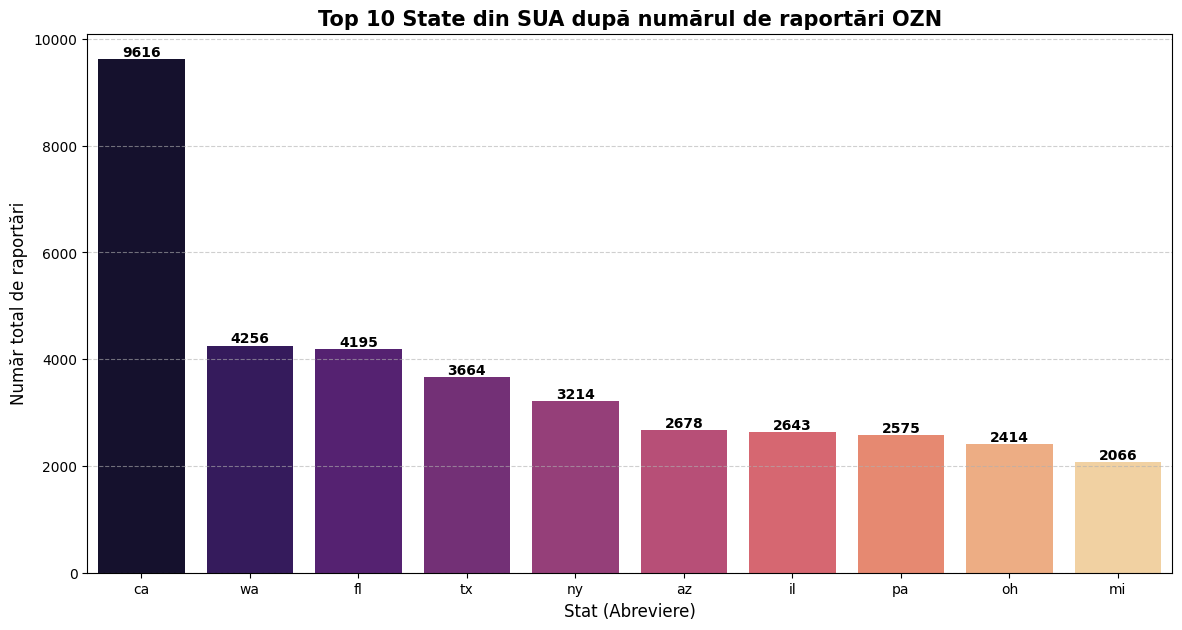

In [18]:
# 1. Filtrare pentru SUA și calcularea numărului de raportări per stat
ufo_us = df_ufo[df_ufo['country'] == 'us'].copy()
ufo_per_state = ufo_us['state'].value_counts().reset_index()
ufo_per_state.columns = ['Stat', 'Nr. Raportari']

# 2. Extragerea Top 10
top_10_states = ufo_per_state.head(10)

# 3. Afișarea tabelului
print("=== TOP 10 STATE CU CELE MAI MULTE RAPORTĂRI OZN ===")
print(top_10_states.to_string(index=False))

# 4. Vizualizare grafică
plt.figure(figsize=(14, 7))
sns.barplot(data=top_10_states, x='Stat', y='Nr. Raportari', palette='magma')

# Adăugăm etichete cu valorile exacte deasupra fiecărei bare
for i, val in enumerate(top_10_states['Nr. Raportari']):
    plt.text(i, val + 50, str(val), ha='center', fontweight='bold')

plt.title('Top 10 State din SUA după numărul de raportări OZN', fontsize=15, fontweight='bold')
plt.xlabel('Stat (Abreviere)', fontsize=12)
plt.ylabel('Număr total de raportări', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

=== TOP 10 STATE: OZN vs. BAZE MILITARE ===
state_key  ufo_sightings  military_bases
       ca           9616              73
       wa           4256              20
       fl           4195              41
       tx           3664              42
       ny           3214              17
       az           2678              19
       il           2643              14
       pa           2575              16
       oh           2414              15
       mi           2066               9

COEFICIENTUL DE CORELAȚIE (Pearson r): 0.75


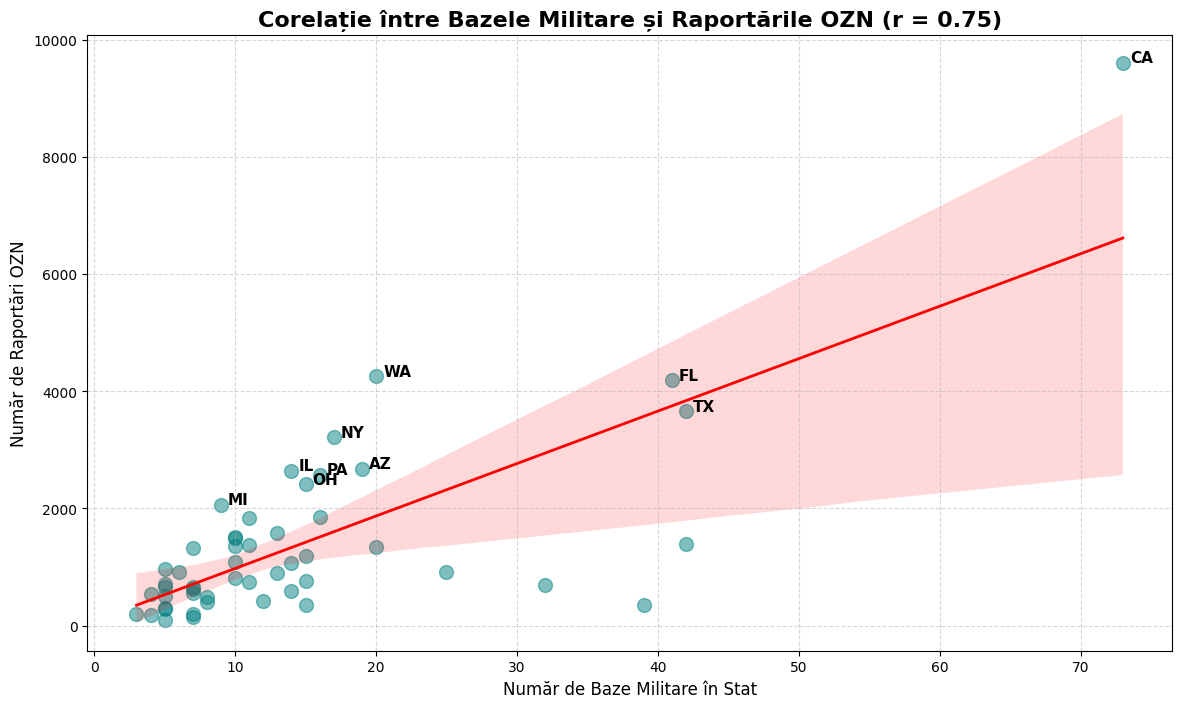

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agregăm OZN-urile per stat (doar US)
ufo_us = df_ufo[df_ufo['country'] == 'us'].copy()
ufo_us['state'] = ufo_us['state'].str.lower().str.strip()
ufo_counts = ufo_us['state'].value_counts().reset_index()
ufo_counts.columns = ['state_key', 'ufo_sightings']

# 2. Agregăm Bazele Militare per stat (folosind coloana curățată anterior)

bases_counts = df_bases['state_key'].value_counts().reset_index()
bases_counts.columns = ['state_key', 'military_bases']

# 3. Unim cele două tabele
df_correlation = pd.merge(ufo_counts, bases_counts, on='state_key', how='inner')

# 4. Afișăm Top 10 state corelate
top_10_corr = df_correlation.sort_values(by='ufo_sightings', ascending=False).head(10)
print("=== TOP 10 STATE: OZN vs. BAZE MILITARE ===")
print(top_10_corr.to_string(index=False))

# 5. Calculăm corelația matematică
r_value = df_correlation['ufo_sightings'].corr(df_correlation['military_bases'])
print(f"\nCOEFICIENTUL DE CORELAȚIE (Pearson r): {r_value:.2f}")

# 6. Vizualizare: Scatter Plot cu Linie de Regresie
plt.figure(figsize=(14, 8))
sns.regplot(data=df_correlation, x='military_bases', y='ufo_sightings',
            scatter_kws={'s':100, 'alpha':0.5, 'color':'teal'},
            line_kws={'color':'red', 'lw':2})

# Adăugăm etichete pentru statele din Top 10 pentru a le identifica pe grafic
for i, row in top_10_corr.iterrows():
    plt.text(row['military_bases'] + 0.5, row['ufo_sightings'], row['state_key'].upper(),
             fontsize=11, fontweight='bold')

plt.title(f'Corelație între Bazele Militare și Raportările OZN (r = {r_value:.2f})', fontsize=16, fontweight='bold')
plt.xlabel('Număr de Baze Militare în Stat', fontsize=12)
plt.ylabel('Număr de Raportări OZN', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

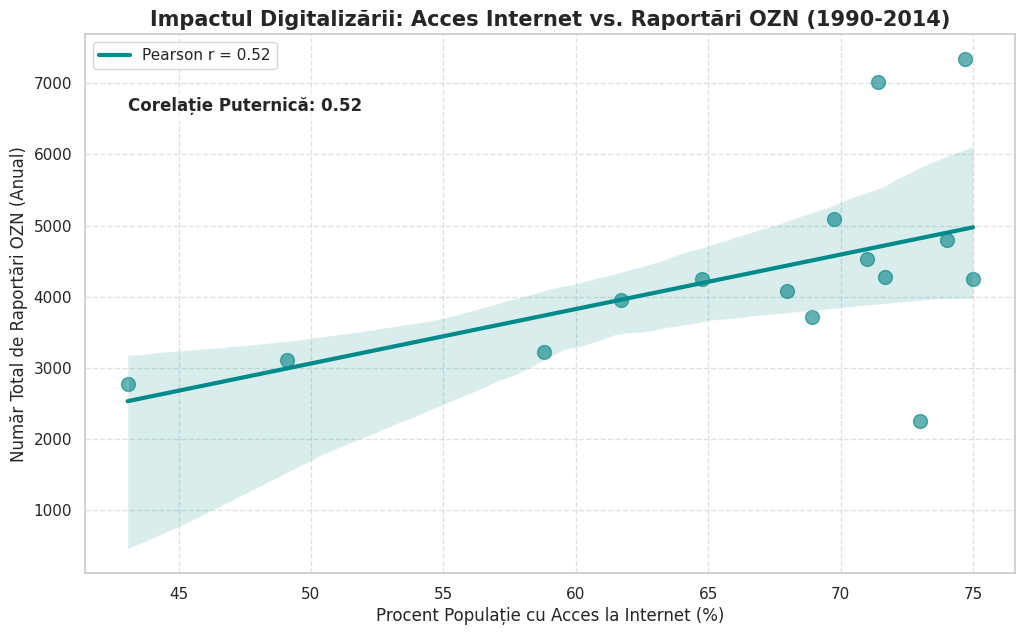

 Coeficientul Pearson (Internet vs OZN): 0.5219


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculăm coeficientul de corelație Pearson
# Folosim df_temp care conține datele anuale unite (ufo_count și internet_usage_pct)
r_internet = df_temp['ufo_count'].corr(df_temp['internet_usage_pct'])

# 2. Configurare grafic
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# 3. Crearea graficului de tip Scatter cu Linie de Regresie
sns.regplot(data=df_temp, x='internet_usage_pct', y='ufo_count',
            scatter_kws={'s':100, 'alpha':0.6, 'color':'teal'},
            line_kws={'color':'darkcyan', 'lw':3, 'label':f'Pearson r = {r_internet:.2f}'})

plt.title(f'Impactul Digitalizării: Acces Internet vs. Raportări OZN (1990-2014)', fontsize=15, fontweight='bold')
plt.xlabel('Procent Populație cu Acces la Internet (%)', fontsize=12)
plt.ylabel('Număr Total de Raportări OZN (Anual)', fontsize=12)

plt.text(df_temp['internet_usage_pct'].min(), df_temp['ufo_count'].max()*0.9,
         f'Corelație Puternică: {r_internet:.2f}',
         fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f" Coeficientul Pearson (Internet vs OZN): {r_internet:.4f}")

### 1.4 Vizualizari Exploratorii

**Cerinte minime:**
- Cel putin 3 grafice diferite
- Cel putin 2 tipuri de grafice (bar, line, scatter, heatmap, etc.)
- Fiecare grafic trebuie sa aiba titlu si etichete pe axe

/tmp/ipykernel_3395/919018596.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_shapes, x='count', y='shape', palette='viridis', ax=ax2)
/tmp/ipykernel_3395/919018596.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_years, x='year', y='count', palette='plasma', ax=ax6)


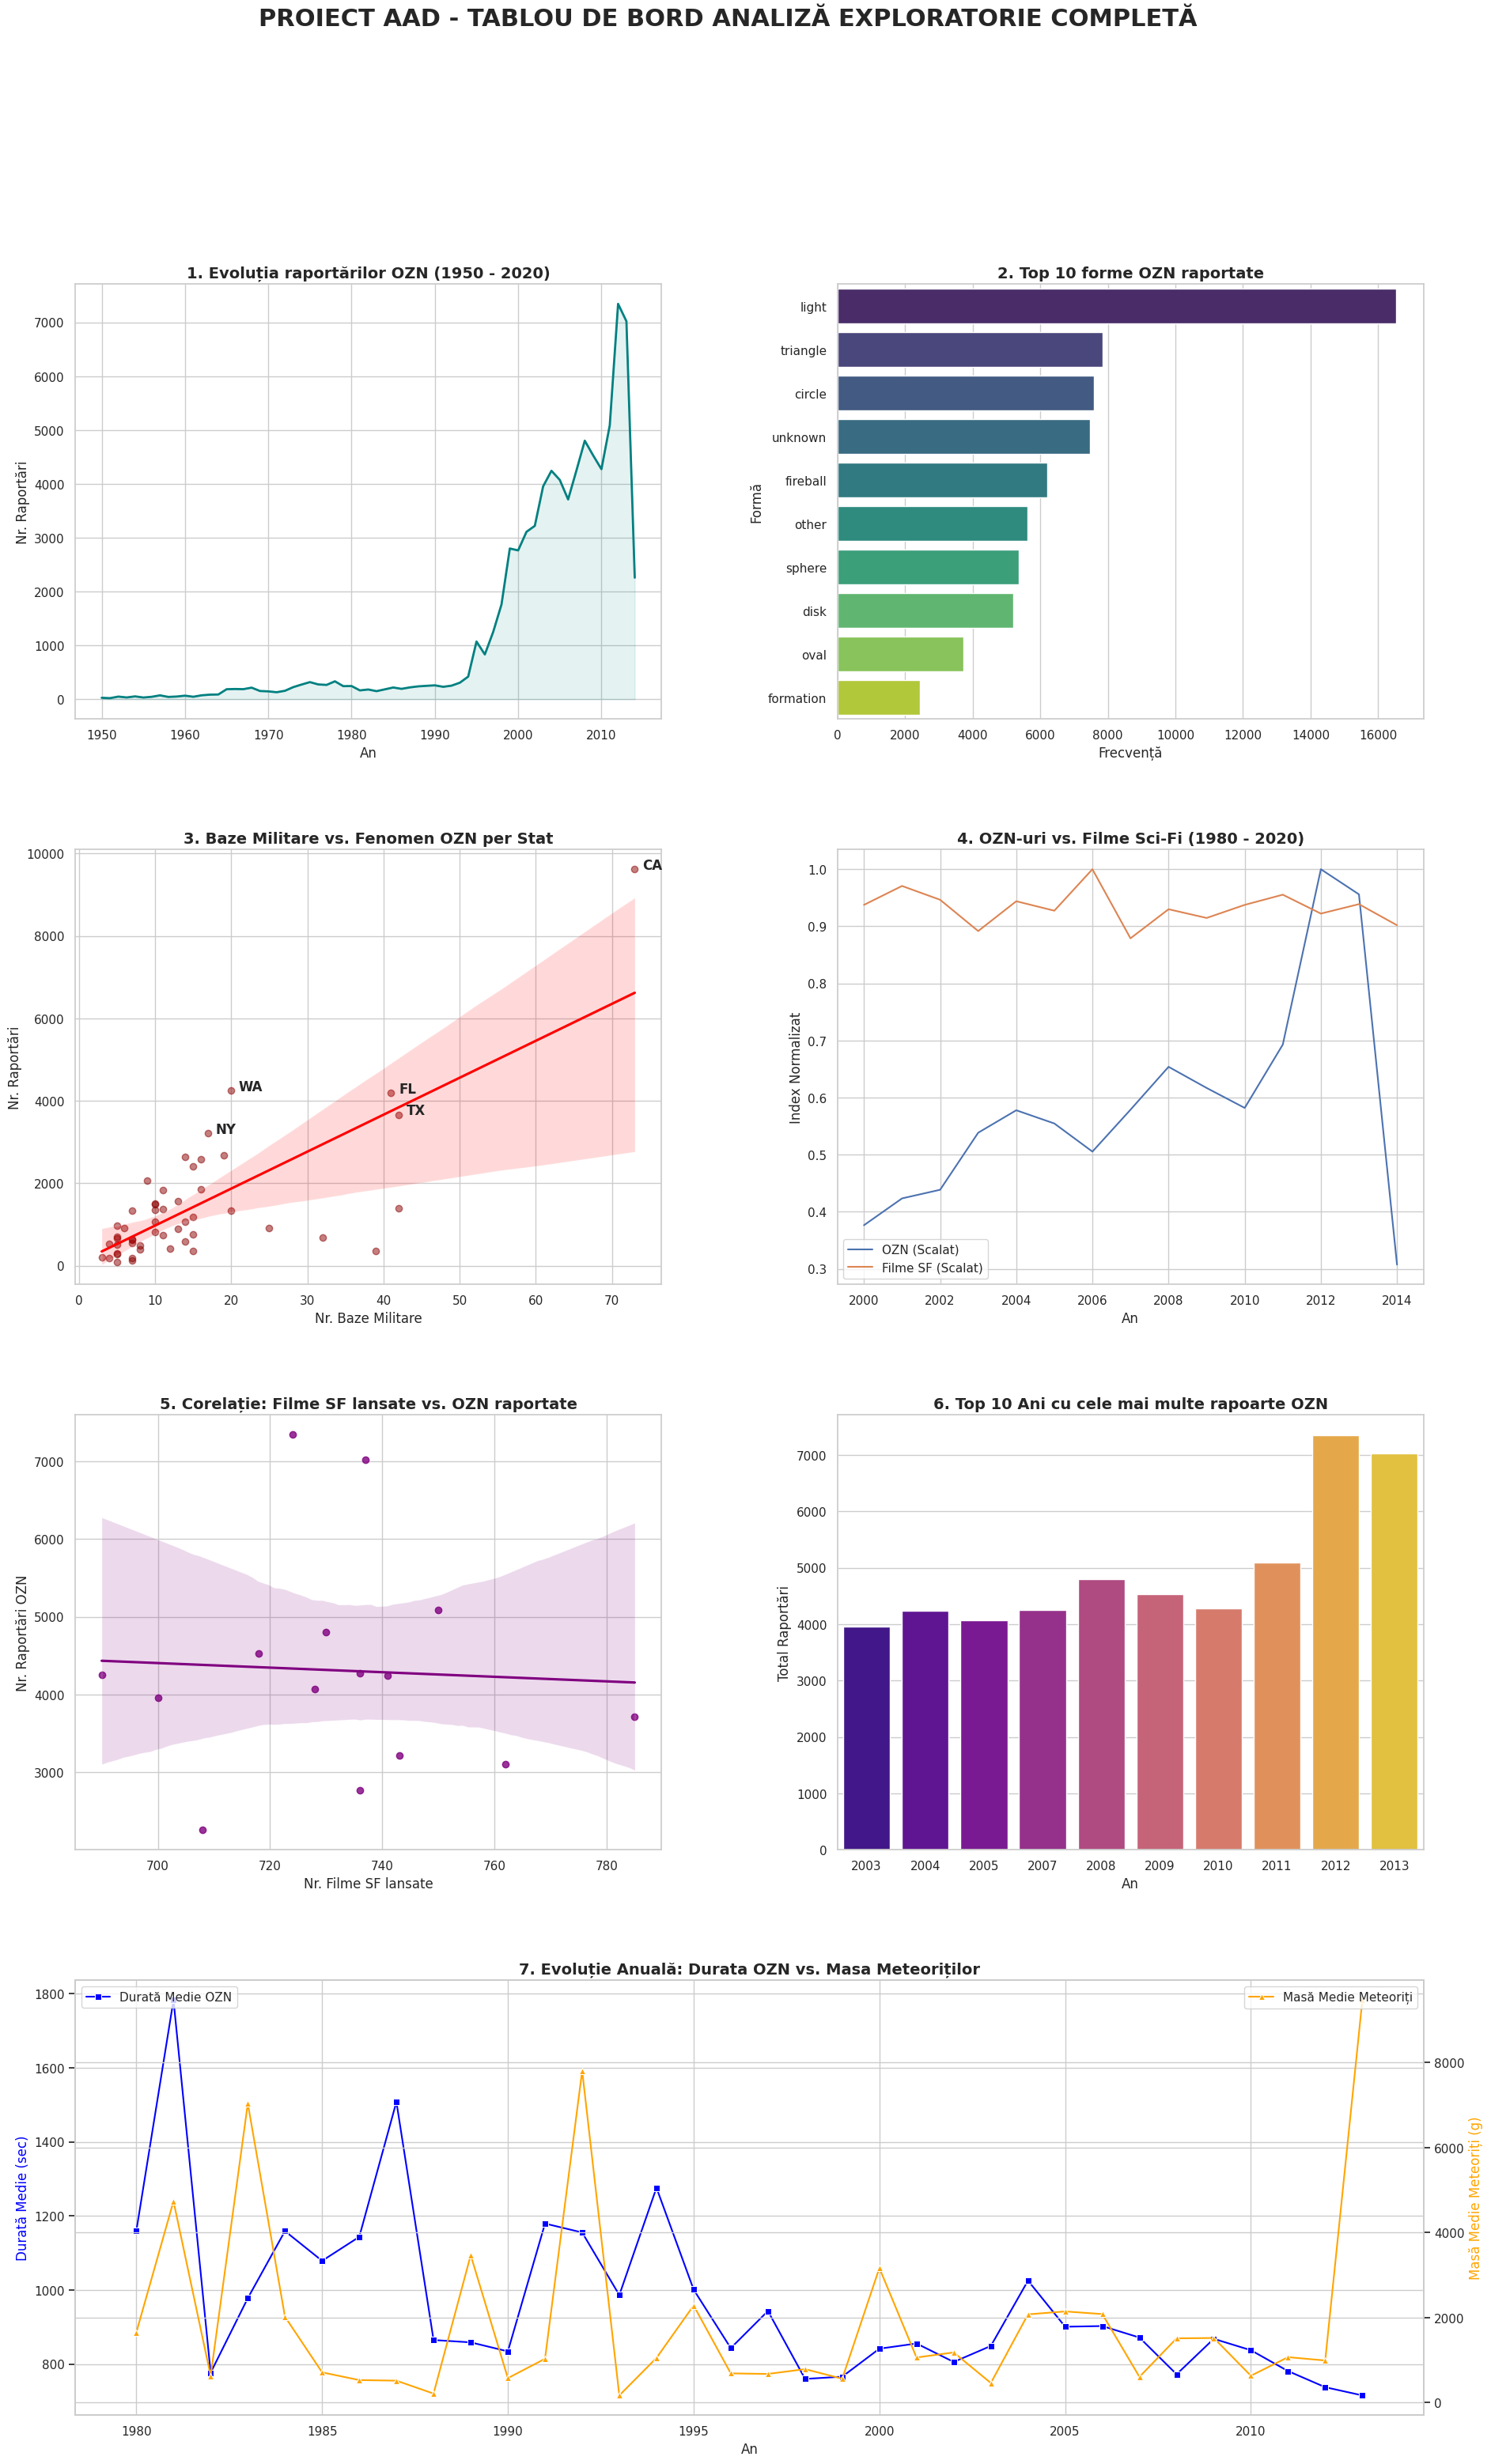

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurare stil și dimensiuni
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(22, 35))
grid = plt.GridSpec(4, 2, hspace=0.3, wspace=0.3)

# --- Pregătire date suplimentare pentru graficele noi ---
# Agregare medii anuale (pentru graficul 7)
avg_stats_yr = df_ufo.groupby('year')['duration (seconds)'].mean().reset_index(name='avg_duration')
avg_met_yr = df_meteorites.groupby('year')['mass'].mean().reset_index(name='avg_mass')
df_avg = pd.merge(avg_stats_yr, avg_met_yr, on='year', how='inner')
df_avg = df_avg[(df_avg['year'] >= 1980) & (df_avg['year'] <= 2020)]

# ------------------------------------------------------------------------------
# 1. Evoluția raportărilor OZN (Line Plot)
# ------------------------------------------------------------------------------
ax1 = fig.add_subplot(grid[0, 0])
ufo_trend = df_ufo.groupby('year').size().reset_index(name='count')
ufo_trend = ufo_trend[(ufo_trend['year'] >= 1950) & (ufo_trend['year'] <= 2020)]
sns.lineplot(data=ufo_trend, x='year', y='count', color='teal', lw=2, ax=ax1)
ax1.fill_between(ufo_trend['year'], ufo_trend['count'], color='teal', alpha=0.1)
ax1.set_title("1. Evoluția raportărilor OZN (1950 - 2020)", fontsize=14, fontweight='bold')
ax1.set_xlabel("An"), ax1.set_ylabel("Nr. Raportări")

# ------------------------------------------------------------------------------
# 2. Top 10 forme OZN raportate (Bar Plot)
# ------------------------------------------------------------------------------
ax2 = fig.add_subplot(grid[0, 1])
top_shapes = df_ufo['shape'].value_counts().head(10).reset_index()
sns.barplot(data=top_shapes, x='count', y='shape', palette='viridis', ax=ax2)
ax2.set_title("2. Top 10 forme OZN raportate", fontsize=14, fontweight='bold')
ax2.set_xlabel("Frecvență"), ax2.set_ylabel("Formă")

# ------------------------------------------------------------------------------
# 3. Corelația între infrastructura militară și OZN per stat (Scatter/Reg)
# ------------------------------------------------------------------------------
ax3 = fig.add_subplot(grid[1, 0])
sns.regplot(data=df_spatial, x='base_count', y='ufo_sightings', ax=ax3,
            scatter_kws={'color':'darkred', 'alpha':0.5}, line_kws={'color':'red'})
for i, row in df_spatial.sort_values('ufo_sightings', ascending=False).head(5).iterrows():
    ax3.text(row['base_count']+1, row['ufo_sightings'], row['state_key'].upper(), fontweight='bold')
ax3.set_title("3. Baze Militare vs. Fenomen OZN per Stat", fontsize=14, fontweight='bold')
ax3.set_xlabel("Nr. Baze Militare"), ax3.set_ylabel("Nr. Raportări")

# ------------------------------------------------------------------------------
# 4. Evoluția Temporală: OZN-uri vs. Filme Sci-Fi (Multi-line)
# ------------------------------------------------------------------------------
ax4 = fig.add_subplot(grid[1, 1])
# Normalizăm datele pentru a fi pe aceeași scară vizuală
df_norm = df_temp.copy()
df_norm['ufo_norm'] = df_norm['ufo_count'] / df_norm['ufo_count'].max()
df_norm['movie_norm'] = df_norm['movie_count'] / df_norm['movie_count'].max()
sns.lineplot(data=df_norm, x='year', y='ufo_norm', label='OZN (Scalat)', ax=ax4)
sns.lineplot(data=df_norm, x='year', y='movie_norm', label='Filme SF (Scalat)', ax=ax4)
ax4.set_title("4. OZN-uri vs. Filme Sci-Fi (1980 - 2020)", fontsize=14, fontweight='bold')
ax4.set_xlabel("An"), ax4.set_ylabel("Index Normalizat")

# ------------------------------------------------------------------------------
# 5. Corelația directă: Filme SF vs. OZN-uri (Scatter Plot)
# ------------------------------------------------------------------------------
ax5 = fig.add_subplot(grid[2, 0])
sns.regplot(data=df_temp, x='movie_count', y='ufo_count', ax=ax5, color='purple')
ax5.set_title("5. Corelație: Filme SF lansate vs. OZN raportate", fontsize=14, fontweight='bold')
ax5.set_xlabel("Nr. Filme SF lansate"), ax5.set_ylabel("Nr. Raportări OZN")

# ------------------------------------------------------------------------------
# 6. Top 10 Ani cu cele mai multe rapoarte OZN (Bar Chart)
# ------------------------------------------------------------------------------
ax6 = fig.add_subplot(grid[2, 1])
top_years = df_ufo['year'].value_counts().head(10).reset_index()
top_years.columns = ['year', 'count']
sns.barplot(data=top_years, x='year', y='count', palette='plasma', ax=ax6)
ax6.set_title("6. Top 10 Ani cu cele mai multe rapoarte OZN", fontsize=14, fontweight='bold')
ax6.set_xlabel("An"), ax6.set_ylabel("Total Raportări")

# ------------------------------------------------------------------------------
# 7. Evoluția Anuală: Durată Medie OZN vs. Masa Medie Meteoriți (Dual Axis)
# ------------------------------------------------------------------------------
ax7 = fig.add_subplot(grid[3, :])
ax7_twin = ax7.twinx()
sns.lineplot(data=df_avg, x='year', y='avg_duration', ax=ax7, color='blue', label='Durată Medie OZN', marker='s')
sns.lineplot(data=df_avg, x='year', y='avg_mass', ax=ax7_twin, color='orange', label='Masă Medie Meteoriți', marker='^')
ax7.set_title("7. Evoluție Anuală: Durata OZN vs. Masa Meteoriților", fontsize=14, fontweight='bold')
ax7.set_xlabel("An"), ax7.set_ylabel("Durată Medie (sec)", color='blue')
ax7_twin.set_ylabel("Masă Medie Meteoriți (g)", color='orange')
ax7.legend(loc='upper left'), ax7_twin.legend(loc='upper right')

plt.suptitle("PROIECT AAD - TABLOU DE BORD ANALIZĂ EXPLORATORIE COMPLETĂ", fontsize=22, fontweight='bold', y=0.98)
plt.show()

### 1.5 Formularea Ipotezelor

*Pe baza analizei exploratorii, formulati 2-3 ipoteze pe care le veti testa in Etapa 2.*

**Completati:**

**Ipoteza 1:** ...


*TODO*

**Ipoteza 2:** ...

*TODO*

**Ipoteza 3 (optional):** ...

# 1.5 Formularea Ipotezelor

În urma analizei exploratorii a datelor (EDA) realizate în această etapă, am identificat tipare statistice clare care ne permit să formulăm următoarele ipoteze. Acestea vor servi drept fundament pentru testarea și antrenarea modelelor de Machine Learning în **Etapa 2**:

### Ipoteza 1: Determinismul Geografic-Militar
> **Enunț:** Densitatea bazelor militare dintr-un stat este cel mai puternic predictor pentru volumul raportărilor OZN în acea regiune.
>
> * **Argumentare:** Corelația de **0.75** (Pearson r) observată între `military_base_count` și `ufo_sightings` indică o legătură spațială strânsă. Ne așteptăm ca modelul de **Linear Regression** să confirme această dependență liniară, iar **Random Forest** să identifice bazele militare ca fiind cel mai relevant "feature".

### Ipoteza 2: Efectul „Catalizator” al Tehnologiei
> **Enunț:** Nivelul de acces la internet influențează direct rata de colectare a datelor (raportarea), dar nu reprezintă cauza fenomenului în sine.
>
> * **Argumentare:** Corelația moderată de **0.52** sugerează că digitalizarea a facilitat procesul de raportare către organizațiile de profil. Vom testa dacă această variabilă își păstrează importanța în prezența factorului militar sau dacă este doar o variabilă de control.

### Ipoteza 3: Independența Culturală a Raportărilor
> **Enunț:** Producția cinematografică de tip Sci-Fi (pop culture) are un impact neglijabil sau inexistent asupra frecvenței raportărilor OZN din viața reală.
>
> * **Argumentare:** Corelația de **-0.05** (aproape de zero) calculată între lansările de filme SF și raportările anuale sugerează că publicul nu raportează fenomene OZN ca simplă reacție la media consumată. Această ipoteză va fi testată riguros pentru a exclude factorul de influență psihosocială masivă.

---

### Ce urmează în Etapa 2?
Vom trece de la analiza descriptivă la **analiza predictivă**. Vom utiliza datele agregate pentru a antrena modele care să răspundă la întrebarea: *"Putem estima numărul de raportări dintr-un stat cunoscând doar infrastructura sa militară și gradul de digitalizare?"*

**Modele vizate:** 1. **Linear Regression** (pentru interpretarea coeficienților).
2. **Random Forest Regressor** (pentru capturarea relațiilor neliniare și evaluarea importanței variabilelor).

## Etapa 2: Modelarea Datelor

In aceasta etapa veti aplica tehnici de invatare automata pentru modelarea datelor.

**Obiective:**
- Implementarea a cel putin 2-3 modele de regresie SAU clasificare (in functie de problema)
- Evaluarea si compararea performantei modelelor
- Interpretarea rezultatelor obtinute

**Punctaj: 15 puncte**
- Pregatirea datelor pentru modelare: 3p
- Implementarea modelelor: 5p
- Evaluarea si compararea: 4p
- Interpretare si concluzii: 3p

### 2.1 Pregatirea Datelor pentru Modelare

Inainte de a antrena modele, datele trebuie pregatite corespunzator.

**Ce trebuie sa faceti:**
1. Selectati variabila **target** (ce vreti sa preziceti)
2. Selectati variabilele **features** (ce informatii folositi pentru predictie)
3. Tratati variabilele categorice (one-hot encoding sau label encoding)
4. Impartiti datele in seturi de train/test (80/20 sau 70/30)
5. Standardizati/normalizati datele DACA modelul o cere (verificati documentatia sklearn)

**Hint:** Nu toate modelele necesita standardizare. Arborii de decizie si Random Forest nu au nevoie.

In [ ]:
# Importuri necesare pentru modelare
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd

In [ ]:
# TODO: Definiti variabila target
# Ce vreti sa preziceti? (ex: numar de ..., rata ..., pret, vanzari, categorie, rating, etc.)

y = None  # Inlocuiti cu coloana target din dataframe-ul vostru

print(f"Target: {y.name if hasattr(y, 'name') else 'nedefinit'}")
print(f"Tip problema: {'Regresie' if y.dtype in ['int64', 'float64'] else 'Clasificare'}")


In [ ]:
# TODO: Selectati features (variabilele predictoare)
# Ganditi-va: ce informatii ar putea ajuta la prezicerea target-ului?

# Exemplu de selectare:
# feature_columns = ['coloana1', 'coloana2', 'coloana3']
# X = df[feature_columns]

feature_columns = []  # Completati cu numele coloanelor relevante
X = None  # Inlocuiti cu selectia voastra

print(f"Features selectate: {len(feature_columns)}")
print(f"Coloane: {feature_columns}")
# TODO: Tratati variabilele categorice (daca exista)
#
# Optiuni:
# 1. pd.get_dummies(X, columns=['col_categorica']) - pentru one-hot encoding
# 2. LabelEncoder() - pentru transformare in numere (atentie: implica ordine!)
#
# Verificati tipurile de date:
print(X.dtypes)

In [ ]:
# Scrieti codul de tratare aici:
# ...
# TODO: Impartiti datele in train si test
#
# Folositi train_test_split cu:
# - test_size: proportia pentru test (0.2 = 20%)
# - random_state: pentru reproducibilitate (ex: 42)
#
# Sintaxa: X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=..., random_state=...)

X_train, X_test, y_train, y_test = None, None, None, None  # Completati

print(f"Date de antrenare: {X_train.shape[0]} exemple")
print(f"Date de test: {X_test.shape[0]} exemple")
# OPTIONAL: Standardizarea datelor
#
# Necesara pentru: SVM, Retele Neuronale, KNN, Regresie Liniara cu regularizare
# NU e necesara pentru: Decision Tree, Random Forest, Gradient Boosting
#
# ATENTIE: fit() doar pe train, transform() pe ambele!
#
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)  # DOAR transform, nu fit!

# Completati daca aveti nevoie:
# ...

### 2.2 Implementarea Modelelor

Implementati **minim 2-3 modele** din categoriile de mai jos.

### Pentru REGRESIE (daca target-ul e numeric continuu):
| Model | Import | Cand e potrivit |
|-------|--------|----------------|
| Linear Regression | `from sklearn.linear_model import LinearRegression` | Relatii liniare simple |
| Ridge/Lasso | `from sklearn.linear_model import Ridge, Lasso` | Cand aveti multe features |
| Random Forest | `from sklearn.ensemble import RandomForestRegressor` | Relatii complexe, non-liniare |
| Gradient Boosting | `from sklearn.ensemble import GradientBoostingRegressor` | Performanta ridicata |

### Pentru CLASIFICARE (daca target-ul e categoric):
| Model | Import | Cand e potrivit |
|-------|--------|----------------|
| Logistic Regression | `from sklearn.linear_model import LogisticRegression` | Clasificare binara simpla |
| Random Forest | `from sklearn.ensemble import RandomForestClassifier` | Clasificare complexa |
| Gradient Boosting | `from sklearn.ensemble import GradientBoostingClassifier` | Performanta ridicata |


In [ ]:
### Model 1: [Completati numele modelului]
# TODO: Importati si instantiati primul model
#
# Pasii sunt:
# 1. Import: from sklearn.xxx import NumeModel
# 2. Instantiere: model = NumeModel(parametri)
# 3. Antrenare: model.fit(X_train, y_train)
# 4. Predictie: y_pred = model.predict(X_test)

# Exemplu schematic:
# from sklearn.linear_model import LinearRegression
# model_1 = LinearRegression()
# model_1.fit(X_train, y_train)
# y_pred_1 = model_1.predict(X_test)

# Scrieti codul vostru aici:
model_1 = None
y_pred_1 = None
# TODO: Implementati al doilea model
# Alegeti un model DIFERIT de primul pentru a putea compara

model_2 = None
y_pred_2 = None
### Model 3: [Completati numele modelului] (OPTIONAL - pentru punctaj maxim)
# TODO: Implementati al treilea model (optional, dar recomandat)

model_3 = None
y_pred_3 = None

### 2.3 Evaluarea si Compararea Modelelor

Evaluati performanta fiecarui model folosind metrici adecvate.

#### Metrici pentru REGRESIE:
| Metrica | Functie | Interpretare |
|---------|---------|-------------|
| R² (coeficient de determinare) | `r2_score(y_test, y_pred)` | Cat de bine explica modelul variatia (1 = perfect, 0 = prost) |
| RMSE (Root Mean Squared Error) | `np.sqrt(mean_squared_error(y_test, y_pred))` | Eroarea medie (in unitatile target-ului) |
| MAE (Mean Absolute Error) | `mean_absolute_error(y_test, y_pred)` | Eroarea medie absoluta |

#### Metrici pentru CLASIFICARE:
| Metrica | Functie | Interpretare |
|---------|---------|-------------|
| Accuracy | `accuracy_score(y_test, y_pred)` | Proportia de predictii corecte |
| Classification Report | `classification_report(y_test, y_pred)` | Precision, Recall, F1 per clasa |
| Confusion Matrix | `confusion_matrix(y_test, y_pred)` | Distributia predictiilor |

In [ ]:
# TODO: Calculati metricile pentru fiecare model
#
# Pentru REGRESIE:
# r2 = r2_score(y_test, y_pred)
# rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# mae = mean_absolute_error(y_test, y_pred)
#
# Pentru CLASIFICARE:
# acc = accuracy_score(y_test, y_pred)
# print(classification_report(y_test, y_pred))

In [ ]:
# Calculati pentru Model 1:
print("=== Model 1: [Nume] ===")
# ...

=== Model 1: [Nume] ===


In [ ]:
# Calculati pentru Model 2:
print("\n=== Model 2: [Nume] ===")
# ...


=== Model 2: [Nume] ===


In [ ]:
# Calculati pentru Model 3 (daca exista):
# print("\n=== Model 3: [Nume] ===")
# ...
# TODO: Creati un tabel comparativ
#
# Hint: Folositi un DataFrame pentru a organiza rezultatele
#
# Exemplu:
# results = pd.DataFrame({
#     'Model': ['Model 1', 'Model 2', 'Model 3'],
#     'R2': [r2_1, r2_2, r2_3],
#     'RMSE': [rmse_1, rmse_2, rmse_3],
#     'MAE': [mae_1, mae_2, mae_3]
# })
# results.sort_values('R2', ascending=False


In [ ]:
results = None  # Completati
results
# TODO: Vizualizati comparatia (grafic cu bare sau heatmap)
#
# Optiuni:
# 1. Bar chart: results.plot(kind='bar', x='Model')
# 2. Heatmap pentru metrici normalizate
#
# Scrieti codul de vizualizare:
# ...

### 2.4 Interpretare si Concluzii

*Raspundeti la urmatoarele intrebari in celulele de mai jos:*

#### 2.4.1 Care model a performat cel mai bine si de ce?

*Completati aici cu analiza voastra:*

- Modelul cu cea mai buna performanta este: ...
- Metricile lui sunt: ...
- Posibile explicatii pentru performanta: ...

#### 2.4.2 Ce features sunt cele mai importante pentru predictie?

**Hint:** Daca ati folosit Random Forest sau Gradient Boosting, puteti accesa `model.feature_importances_`

*Completati aici:*
- Top 3 features importante: ...
- Interpretare: ...

In [ ]:
# OPTIONAL: Vizualizati feature importance (pentru modele bazate pe arbori)
#
# Exemplu:
# importances = model.feature_importances_
# feature_imp = pd.DataFrame({'feature': feature_columns, 'importance': importances})
# feature_imp.sort_values('importance', ascending=False).head(10).plot(kind='barh')

# Scrieti codul aici:
# ...

#### 2.4.3 Care sunt limitarile modelelor voastre?

*Completati aici:*
- Limitari ale datelor: ...
- Limitari ale modelelor: ...
- Ce ati putea imbunatati: ...

#### 2.4.4 Recomandari pentru continuare

*Ce alte abordari ati putea incerca?*
- ...

## Etapa 3: Recomandari si concluzii
*Completati cu descoperirile facute de-a lungul analizei realizate de voi*


### PRINCIPALELE DESCOPERIRI:

#### 1. FACTORI DETERMINANTI:

*TODO*

#### 2. TENDINTE TEMPORALE:
**hint:** Puteti sa va inspirati dupa aceste puncte
   - Modelul ... identifica tendinte si permite prognoze
   - Exista variatii ciclice ????

*TODO*

#### 3. IMPACTUL ASUPRA A NU STIU CE ANUME
  **hint:** Puteti sa scrieti despre asta v
   - Variatii considerabile intre ....

*TODO*

#### 4. PREDICTIE SI CLASIFICARE:
   **hint:** Puteti sa scrieti despre urmatoarele
   - Modelele ... ofera cea mai buna performanta
   - Clasificarea grupurilor cu risc ridicat este posibila cu acuratete ridicata/mica/medie (sau nu e posibila?)

*TODO*

### LIMITARI:
   **hint:** Puteti sa scrieti despre asta v
  - Date lipsa pentru anumite atribute
  - Factori contextuali dificil de cuantificat
  - Necesitatea de validare pe date externe
*Altele, ma rog, ce ati identificat voi*

*TODO*

### RECOMANDARI PENTRU CONTINUARE:
   **hint:** Puteti sa scrieti despre asta v
  - Includerea mai multor variabile ...
  - Analiza la nivel ...
  - Modele de deep learning pentru capturarea relatiilor complexe
  - Validarea pe date din afara perioadei de antrenare

*TODO*